In [1]:
import numpy as np
import pandas as pd

In [2]:
crop = pd.read_csv("Crop_recommendation.csv")
crop.head()

,N,P,K,Temperature,Humidity,ph,Rainfall,Label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
crop.shape

(2200, 8)

In [4]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
crop.isnull().sum()

N              0
P              0
K              0
Temperature    0
Humidity       0
ph             0
Rainfall       0
Label          0
dtype: int64

In [6]:
crop.duplicated().sum()

0

In [7]:
crop.describe()

,N,P,K,Temperature,Humidity,ph,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
crop['Label'].value_counts()

Label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [9]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}
crop['crop_num'] = crop['Label'].map(crop_dict)

In [10]:
crop

,N,P,K,Temperature,Humidity,ph,Rainfall,Label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,22


In [11]:
crop.drop(['Label'],axis=1,inplace=True)
crop.head()

,N,P,K,Temperature,Humidity,ph,Rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [12]:
X = crop.drop(['crop_num'],axis=1)
y = crop['crop_num']

In [13]:
X

,N,P,K,Temperature,Humidity,ph,Rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [14]:
y

0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: crop_num, Length: 2200, dtype: int64

In [15]:
y.shape

(2200,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train

,N,P,K,Temperature,Humidity,ph,Rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430


In [19]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

In [20]:
X_train

array([[0.12142857, 0.07857143, 0.045     , ..., 0.9089898 , 0.48532225,
        0.29685161],
       [0.26428571, 0.52857143, 0.07      , ..., 0.64257946, 0.56594073,
        0.17630752],
       [0.05      , 0.48571429, 0.1       , ..., 0.57005802, 0.58835229,
        0.08931844],
       ...,
       [0.07857143, 0.22142857, 0.13      , ..., 0.43760347, 0.46198144,
        0.28719815],
       [0.07857143, 0.85      , 0.995     , ..., 0.76763665, 0.44420505,
        0.18346657],
       [0.22857143, 0.52142857, 0.085     , ..., 0.56099735, 0.54465022,
        0.11879596]])

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [22]:
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
ypred = rfc.predict(X_test)
accuracy_score(y_test,ypred)

0.9931818181818182

In [23]:
def recommendation(N,P,k,temperature,humidity,ph,rainfal):
    features = np.array([[N,P,k,temperature,humidity,ph,rainfal]])
    transformed_features = ms.fit_transform(features)
    prediction = rfc.predict(transformed_features)
    print(prediction)
    return prediction[0]

In [24]:
# new inputs


N = 40
P = 50
k = 50
temperature = 40.0
humidity = 20
ph = 100
rainfall = 100

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[20]
Kidneybeans is a best crop to be cultivated 


In [25]:
# new inputs 2


N = 100
P = 90
k = 100
temperature = 50.0
humidity = 90.0
ph = 100
rainfall = 202.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[20]
Kidneybeans is a best crop to be cultivated 


In [26]:
import joblib
# Save the model and scaler using joblib
joblib.dump(rfc, 'rfc_model.joblib')  # Save RandomForest model
joblib.dump(ms, 'minmaxscaler.joblib')  # Save MinMaxScaler

['minmaxscaler.joblib']

In [27]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import joblib

In [28]:
# Update this path after uploading your zip & extracting
data_dir = "preprocessed_dataset"
img_height, img_width = 150, 150
batch_size = 16

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)



Found 689 images belonging to 8 classes.
Found 168 images belonging to 8 classes.


D:\miniconda3\envs\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60


D:\miniconda3\envs\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 248ms/step - accuracy: 0.2085 - loss: 1.9627 - val_accuracy: 0.4881 - val_loss: 1.3136 - learning_rate: 0.0010
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.5022 - loss: 1.3098 - val_accuracy: 0.4940 - val_loss: 1.2374 - learning_rate: 0.0010
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.5949 - loss: 1.0801 - val_accuracy: 0.7083 - val_loss: 0.9604 - learning_rate: 0.0010
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.7239 - loss: 0.8251 - val_accuracy: 0.6131 - val_loss: 1.0518 - learning_rate: 0.0010
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.6982 - loss: 0.7662 - val_accuracy: 0.7024 - val_loss: 0.8586 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.7554 - loss: 0.7228 - val_accuracy: 0.7381 - val_loss: 0.8413 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.7507 - loss: 0.6679 - val_accura

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7692 - loss: 0.7599
Validation Loss: 0.8413236737251282
Validation Accuracy: 0.738095223903656
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


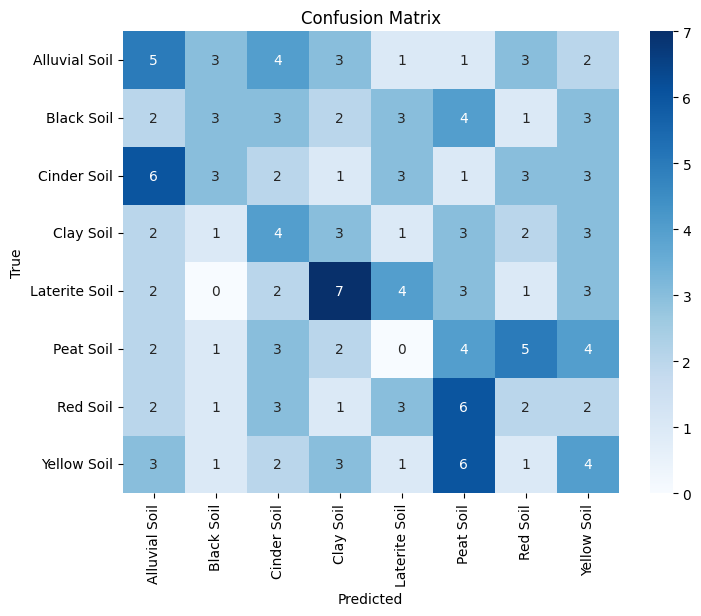


Classification Report:
               precision    recall  f1-score   support

Alluvial Soil       0.21      0.23      0.22        22
   Black Soil       0.23      0.14      0.18        21
  Cinder Soil       0.09      0.09      0.09        22
    Clay Soil       0.14      0.16      0.15        19
Laterite Soil       0.25      0.18      0.21        22
    Peat Soil       0.14      0.19      0.16        21
     Red Soil       0.11      0.10      0.11        20
  Yellow Soil       0.17      0.19      0.18        21

     accuracy                           0.16       168
    macro avg       0.17      0.16      0.16       168
 weighted avg       0.17      0.16      0.16       168



In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

cnn_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Fit the model with callbacks
history = cnn_model.fit(train_data, validation_data=val_data, epochs=60,
                        callbacks=[early_stopping, lr_scheduler])

# Save the model
cnn_model.save("soil_cnn_model.h5")

# Evaluate the model
val_loss, val_accuracy = cnn_model.evaluate(val_data)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Get predictions on validation data
val_predictions = cnn_model.predict(val_data)
val_predictions_classes = np.argmax(val_predictions, axis=1)

# Confusion Matrix
y_true = val_data.classes  # Ground truth labels from validation data
cm = confusion_matrix(y_true, val_predictions_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_data.class_indices, yticklabels=val_data.class_indices)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, val_predictions_classes, target_names=val_data.class_indices.keys()))


In [30]:
# Soil label mapping for decoding predictions
soil_label_map = train_data.class_indices
soil_label_map = {v: k for k, v in soil_label_map.items()}

In [31]:
# Function to predict soil type from image
def predict_soil_type(img_path):
    img = load_img(img_path, target_size=(img_height, img_width))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = cnn_model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_label = soil_label_map[predicted_class_index]
    return predicted_label

In [32]:
# Crop dictionary
crop_dict = {
    1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
    8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
    14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
    19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"
}

In [33]:
# Final recommendation function
def recommend_crop(img_path, npk_ph_temp_humidity, model):
    soil_type = predict_soil_type(img_path)
    print("Predicted Soil Type:", soil_type)

    soil_to_id = {'Alluvial Soil': 1, 'Black Soil': 2, 'Cinder Soil': 3, 'Clay Soil': 4,
                  'Laterite Soil': 5, 'Peat Soil': 6, 'Red Soil': 7, 'Yellow Soil': 8}

    soil_id = soil_to_id.get(soil_type, 1)  # Default to 1 if not found
    input_features = [soil_id] + npk_ph_temp_humidity
    prediction = model.predict([input_features])[0]
    return crop_dict[prediction]

In [34]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML

# 📚 Load Trained Models
cnn_model = tf.keras.models.load_model('soil_cnn_model.h5')
rfc_model = joblib.load('rfc_model.joblib')
ms = joblib.load('minmaxscaler.joblib')

# 🧠 Soil Type Mappings
soil_dict = {'Alluvial': 1, 'Black': 2, 'Cinder': 3, 'Clay': 4, 'Laterite': 5,
             'peat': 6, 'Read': 7, 'Yellow': 8}

crop_dict = {1: 'rice', 2: 'maize', 3: 'chickpea', 4: 'kidneybeans', 5: 'pigeonpeas',
             6: 'mothbeans', 7: 'mungbean', 8: 'blackgram', 9: 'lentil', 10: 'pomegranate',
             11: 'banana', 12: 'mango', 13: 'grapes', 14: 'watermelon', 15: 'muskmelon',
             16: 'apple', 17: 'orange', 18: 'papaya', 19: 'coconut', 20: 'cotton',
             21: 'jute', 22: 'coffee'}

# 🧠 Soil → Compatible Crops Mapping
soil_crop_mapping = {
    'Alluvial': ['Rice', 'Wheat', 'Sugarcane', 'Cotton', 'Jute', 'Pulses'],
    'Black': ['Cotton', 'Soybean', 'Sorghum', 'Millets'],
    'Cinder': ['Grapes', 'Apple'],
    'Clay': ['Rice', 'Sugarcane'],
    'Laterite': ['Tea', 'Coffee', 'Cashew'],
    'peat': ['Rice', 'Vegetables'],
    'Read': ['Millets', 'Groundnut', 'Pulses'],
    'Yellow': ['Maize', 'Peanuts', 'Pulses']
}

# 🖼️ Soil Prediction
def predict_soil_type(image_path):
    img = Image.open(image_path).resize((150, 150))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
    prediction = cnn_model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    soil_label = list(soil_dict.keys())[predicted_class_index]
    return soil_label

# 🌾 Crop Recommendation from Inputs
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    transformed_features = ms.transform(features)
    crop_pred = rfc_model.predict(transformed_features)[0]
    crop_name = crop_dict[crop_pred]
    return crop_name

# 📤 Display Soil Compatibility Table
def display_soil_crop_table():
    html = "<h4>🌱 Soil to Compatible Crops</h4><table><tr><th>Soil Type</th><th>Compatible Crops</th></tr>"
    for soil, crops in soil_crop_mapping.items():
        html += f"<tr><td><b>{soil}</b></td><td>{', '.join(crops)}</td></tr>"
    html += "</table>"
    display(HTML(html))

# 🧑‍🌾 Input Widgets
upload = widgets.FileUpload(accept='image/*', multiple=False)

N_text = widgets.FloatText(description='Nitrogen (N)', placeholder='e.g., 50')
P_text = widgets.FloatText(description='Phosphorus (P)', placeholder='e.g., 30')
K_text = widgets.FloatText(description='Potassium (K)', placeholder='e.g., 20')
temp_text = widgets.FloatText(description='Temperature (°C)', placeholder='e.g., 25.0')
humidity_text = widgets.FloatText(description='Humidity (%)', placeholder='e.g., 50.0')
ph_text = widgets.FloatText(description='pH Level', placeholder='e.g., 6.5')
rainfall_text = widgets.FloatText(description='Rainfall (mm)', placeholder='e.g., 100.0')

submit_btn = widgets.Button(description="🚀 Predict")
output = widgets.Output()

# 🎯 Prediction Handler
def on_submit_clicked(b):
    with output:
        output.clear_output()
        
        soil_type = None
        metadata_available = all([
            N_text.value, P_text.value, K_text.value, temp_text.value,
            humidity_text.value, ph_text.value, rainfall_text.value
        ])

        # Check if image uploaded
        if upload.value:
            image_bytes = upload.value[0]['content']
            image_path = "temp_uploaded_image.jpg"
            with open(image_path, 'wb') as f:
                f.write(image_bytes)
            soil_type = predict_soil_type(image_path)
            print(f"🧱 Predicted Soil Type: {soil_type}")

        # Cases
        if soil_type and metadata_available:
            recommended_crop = recommend_crop(
                N=N_text.value,
                P=P_text.value,
                K=K_text.value,
                temperature=temp_text.value,
                humidity=humidity_text.value,
                ph=ph_text.value,
                rainfall=rainfall_text.value
            )
            print(f"🌾 Recommended Crop based on Soil and Inputs: {recommended_crop.title()}")

        elif soil_type and not metadata_available:
            crops = soil_crop_mapping.get(soil_type, ["No data available"])
            print(f"🌾 Compatible Crops for {soil_type}: {', '.join(crops)}")

        elif not soil_type and metadata_available:
            recommended_crop = recommend_crop(
                N=N_text.value,
                P=P_text.value,
                K=K_text.value,
                temperature=temp_text.value,
                humidity=humidity_text.value,
                ph=ph_text.value,
                rainfall=rainfall_text.value
            )
            print(f"🌾 Recommended Crop based on Environmental Inputs: {recommended_crop.title()}")

        else:
            print("⚠️ Please upload a soil image or provide environmental parameters!")

submit_btn.on_click(on_submit_clicked)

# 📤 Display Widgets
display(HTML("<h3>📷 Upload Soil Image & Enter Parameters (Optional)</h3>"))
display(upload, N_text, P_text, K_text, temp_text, humidity_text, ph_text, rainfall_text, submit_btn, output)

# 📖 Show Soil → Crop Table
display_soil_crop_table()


FileUpload(value=(), accept='image/*', description='Upload')

FloatText(value=0.0, description='Nitrogen (N)')

FloatText(value=0.0, description='Phosphorus (P)')

FloatText(value=0.0, description='Potassium (K)')

FloatText(value=0.0, description='Temperature (°C)')

...

FloatText(value=0.0, description='pH Level')

FloatText(value=0.0, description='Rainfall (mm)')

Button(description='🚀 Predict', style=ButtonStyle())

Output()

Soil Type,Compatible Crops
Alluvial,"Rice, Wheat, Sugarcane, Cotton, Jute, Pulses"
Black,"Cotton, Soybean, Sorghum, Millets"
Cinder,"Grapes, Apple"
Clay,"Rice, Sugarcane"
Laterite,"Tea, Coffee, Cashew"
peat,"Rice, Vegetables"
Read,"Millets, Groundnut, Pulses"
Yellow,"Maize, Peanuts, Pulses"
